In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [12]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import os

print("=" * 50)
print("  RETAIL SALES INTELLIGENCE SYSTEM")
print("=" * 50)

# Synthetic data generate karega automatically
np.random.seed(42)
n = 9994
categories = ["Furniture", "Office Supplies", "Technology"]
sub_cats = {
    "Furniture": ["Bookcases", "Chairs", "Tables", "Furnishings"],
    "Office Supplies": ["Labels", "Storage", "Art", "Binders", "Paper"],
    "Technology": ["Accessories", "Machines", "Phones", "Copiers"],
}
segments = ["Consumer", "Corporate", "Home Office"]
regions = ["West", "East", "Central", "South"]
ships = ["Standard Class", "Second Class", "First Class", "Same Day"]

cat_col = np.random.choice(categories, n)
sub_col = [np.random.choice(sub_cats[c]) for c in cat_col]
sales_base = {"Furniture": 400, "Office Supplies": 80, "Technology": 600}
sales_col = np.array([max(10, np.random.exponential(sales_base[c])) for c in cat_col])
disc_col = np.round(np.random.choice([0,0.1,0.2,0.3,0.4,0.5], n, p=[0.4,0.2,0.2,0.1,0.05,0.05]), 2)
profit_col = sales_col * (np.random.uniform(0.05, 0.35, n) - disc_col * 0.5)
qty_col = np.random.randint(1, 15, n)
dates = pd.date_range("2019-01-01", "2022-12-31", periods=n)

df = pd.DataFrame({
    "Order_ID": [f"CA-{np.random.randint(2019,2023)}-{np.random.randint(100000,999999)}" for _ in range(n)],
    "Order_Date": dates,
    "Ship_Date": dates + pd.to_timedelta(np.random.randint(1,8,n), unit="D"),
    "Ship_Mode": np.random.choice(ships, n),
    "Segment": np.random.choice(segments, n),
    "Region": np.random.choice(regions, n),
    "Category": cat_col,
    "Sub_Category": sub_col,
    "Sales": np.round(sales_col, 2),
    "Quantity": qty_col,
    "Discount": disc_col,
    "Profit": np.round(profit_col, 2),
})

print(f"\n✅ Data loaded: {len(df):,} rows × {df.shape[1]} columns")
print(df.head())

  RETAIL SALES INTELLIGENCE SYSTEM

✅ Data loaded: 9,994 rows × 12 columns
         Order_ID                    Order_Date                     Ship_Date  \
0  CA-2020-557435 2019-01-01 00:00:00.000000000 2019-01-03 00:00:00.000000000   
1  CA-2019-705403 2019-01-01 03:30:23.236265385 2019-01-03 03:30:23.236265385   
2  CA-2021-394323 2019-01-01 07:00:46.472530771 2019-01-08 07:00:46.472530771   
3  CA-2022-105243 2019-01-01 10:31:09.708796157 2019-01-03 10:31:09.708796157   
4  CA-2020-294155 2019-01-01 14:01:32.945061543 2019-01-05 14:01:32.945061543   

        Ship_Mode      Segment Region    Category Sub_Category    Sales  \
0  Standard Class  Home Office   West  Technology     Machines  2620.35   
1  Standard Class  Home Office   West   Furniture       Tables   328.29   
2     First Class    Corporate   West  Technology  Accessories   713.72   
3  Standard Class  Home Office   East  Technology     Machines    75.61   
4     First Class  Home Office  South   Furniture       Chairs 

In [14]:
cols = ["Sales", "Profit", "Quantity", "Discount"]
summary = df[cols].describe()
print(summary.round(2))

         Sales   Profit  Quantity  Discount
count  9994.00  9994.00   9994.00   9994.00
mean    357.08    47.35      7.48      0.14
std     464.30    91.02      4.01      0.15
min      10.00  -447.29      1.00      0.00
25%      59.49     2.94      4.00      0.00
50%     174.90    15.97      7.00      0.10
75%     484.46    57.12     11.00      0.20
max    4582.70  1499.53     14.00      0.50


In [15]:
# STEP 3: FEATURE ENGINEERING
print("[STEP 3] Feature Engineering...")

df["Order_Year"]    = df["Order_Date"].dt.year
df["Order_Month"]   = df["Order_Date"].dt.month
df["Order_Quarter"] = df["Order_Date"].dt.quarter
df["Shipping_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days

df["Profit_Margin"]    = (df["Profit"] / df["Sales"]).round(4)
df["Revenue_per_Unit"] = (df["Sales"] / df["Quantity"]).round(2)

df["Discount_Tier"] = pd.cut(df["Discount"],
    bins=[-0.01, 0, 0.2, 0.4, 1.0],
    labels=["No Discount", "Low", "Medium", "High"])

le = LabelEncoder()
df["Category_Enc"]  = le.fit_transform(df["Category"])
df["Segment_Enc"]   = le.fit_transform(df["Segment"])
df["Region_Enc"]    = le.fit_transform(df["Region"])
df["Ship_Mode_Enc"] = le.fit_transform(df["Ship_Mode"])

print(f"✅ New columns added: {list(df.columns)}")
print(f"\nSample data:")
print(df[["Sales","Profit","Profit_Margin","Shipping_Days","Discount_Tier"]].head())

[STEP 3] Feature Engineering...
✅ New columns added: ['Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Segment', 'Region', 'Category', 'Sub_Category', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order_Year', 'Order_Month', 'Order_Quarter', 'Shipping_Days', 'Profit_Margin', 'Revenue_per_Unit', 'Discount_Tier', 'Category_Enc', 'Segment_Enc', 'Region_Enc', 'Ship_Mode_Enc']

Sample data:
     Sales  Profit  Profit_Margin  Shipping_Days Discount_Tier
0  2620.35  739.22         0.2821              2           Low
1   328.29   12.98         0.0395              2           Low
2   713.72  -30.80        -0.0432              7        Medium
3    75.61   10.20         0.1349              2           Low
4   115.42   19.52         0.1691              4           Low


In [16]:
# STEP 4: SQLite DATABASE
import sqlite3

conn = sqlite3.connect("retail_sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)
print("✅ Database ready!")

# Query 1
q1 = pd.read_sql_query("""
    SELECT Category,
           ROUND(SUM(Sales),2) AS Total_Sales,
           ROUND(SUM(Profit),2) AS Total_Profit
    FROM sales
    GROUP BY Category
    ORDER BY Total_Sales DESC
""", conn)
print("\n📊 Category Performance:")
print(q1)

# Query 2
q2 = pd.read_sql_query("""
    SELECT Region,
           ROUND(SUM(Sales),2) AS Revenue,
           ROUND(SUM(Profit),2) AS Profit
    FROM sales
    GROUP BY Region
    ORDER BY Revenue DESC
""", conn)
print("\n🌍 Region Performance:")
print(q2)

conn.close()
print("\n✅ SQL Queries Done!")

✅ Database ready!

📊 Category Performance:
          Category  Total_Sales  Total_Profit
0       Technology   1960603.04     262624.71
1        Furniture   1338749.24     176652.22
2  Office Supplies    269290.12      33974.12

🌍 Region Performance:
    Region    Revenue     Profit
0     West  902125.99  120136.83
1    South  901118.10  120386.33
2  Central  894040.28  120220.54
3     East  871358.03  112507.35

✅ SQL Queries Done!


In [17]:
# STEP 4: SQLite DATABASE
import sqlite3

conn = sqlite3.connect("retail_sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)
print("✅ Database ready!")

# Query 1
q1 = pd.read_sql_query("""
    SELECT Category,
           ROUND(SUM(Sales),2) AS Total_Sales,
           ROUND(SUM(Profit),2) AS Total_Profit
    FROM sales
    GROUP BY Category
    ORDER BY Total_Sales DESC
""", conn)
print("\n📊 Category Performance:")
print(q1)

# Query 2
q2 = pd.read_sql_query("""
    SELECT Region,
           ROUND(SUM(Sales),2) AS Revenue,
           ROUND(SUM(Profit),2) AS Profit
    FROM sales
    GROUP BY Region
    ORDER BY Revenue DESC
""", conn)
print("\n🌍 Region Performance:")
print(q2)

conn.close()
print("\n✅ SQL Queries Done!")

✅ Database ready!

📊 Category Performance:
          Category  Total_Sales  Total_Profit
0       Technology   1960603.04     262624.71
1        Furniture   1338749.24     176652.22
2  Office Supplies    269290.12      33974.12

🌍 Region Performance:
    Region    Revenue     Profit
0     West  902125.99  120136.83
1    South  901118.10  120386.33
2  Central  894040.28  120220.54
3     East  871358.03  112507.35

✅ SQL Queries Done!


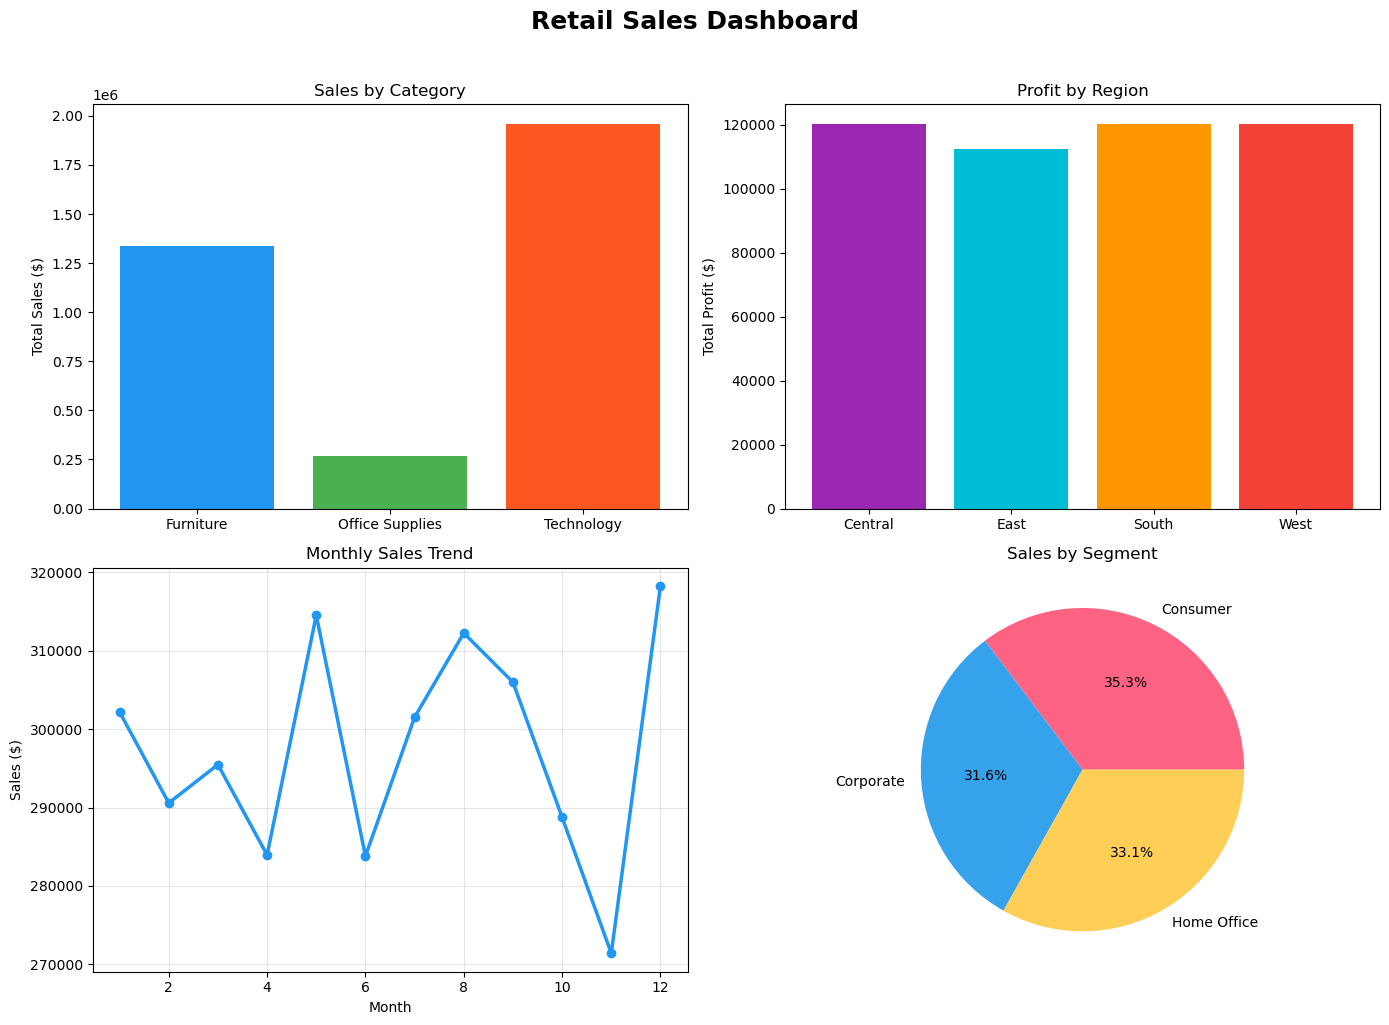

✅ Charts ready!


In [18]:
# STEP 5: VISUALIZATIONS
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Retail Sales Dashboard", fontsize=18, fontweight="bold", y=1.02)

# Chart 1 - Category Sales
cat_sales = df.groupby("Category")["Sales"].sum()
axes[0,0].bar(cat_sales.index, cat_sales.values, 
              color=["#2196F3","#4CAF50","#FF5722"])
axes[0,0].set_title("Sales by Category")
axes[0,0].set_ylabel("Total Sales ($)")

# Chart 2 - Region Profit
reg_profit = df.groupby("Region")["Profit"].sum()
axes[0,1].bar(reg_profit.index, reg_profit.values,
              color=["#9C27B0","#00BCD4","#FF9800","#F44336"])
axes[0,1].set_title("Profit by Region")
axes[0,1].set_ylabel("Total Profit ($)")

# Chart 3 - Monthly Sales Trend
monthly = df.groupby("Order_Month")["Sales"].sum()
axes[1,0].plot(monthly.index, monthly.values, 
               color="#2196F3", linewidth=2.5, marker="o")
axes[1,0].set_title("Monthly Sales Trend")
axes[1,0].set_xlabel("Month")
axes[1,0].set_ylabel("Sales ($)")
axes[1,0].grid(True, alpha=0.3)

# Chart 4 - Segment Pie
seg_sales = df.groupby("Segment")["Sales"].sum()
axes[1,1].pie(seg_sales, labels=seg_sales.index,
              autopct="%1.1f%%",
              colors=["#FF6384","#36A2EB","#FFCE56"])
axes[1,1].set_title("Sales by Segment")

plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Charts ready!")

In [19]:
# STEP 6: LINEAR REGRESSION MODEL
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Features aur Target
features = ["Quantity", "Discount", "Shipping_Days",
            "Category_Enc", "Segment_Enc", 
            "Region_Enc", "Ship_Mode_Enc",
            "Order_Month", "Order_Quarter"]

X = df[features]
y = df["Profit"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Model Train
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Results
r2   = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("=" * 40)
print("   MODEL RESULTS")
print("=" * 40)
print(f"✅ R² Score  : {r2:.4f}")
print(f"✅ RMSE      : ${rmse:.2f}")
print("=" * 40)

# Feature Importance
import pandas as pd
coef = pd.DataFrame({
    "Feature": features,
    "Impact" : model.coef_.round(2)
}).sort_values("Impact", ascending=False)

print("\n📊 Feature Impact on Profit:")
print(coef.to_string(index=False))

   MODEL RESULTS
✅ R² Score  : 0.0951
✅ RMSE      : $82.96

📊 Feature Impact on Profit:
      Feature  Impact
 Category_Enc   13.70
  Order_Month    1.27
   Region_Enc    0.34
  Segment_Enc   -0.02
     Quantity   -0.04
Shipping_Days   -0.28
Ship_Mode_Enc   -0.36
Order_Quarter   -3.64
     Discount -181.07


In [20]:
# STEP 7: BUSINESS INSIGHTS
print("=" * 45)
print("   BUSINESS INSIGHTS SUMMARY")
print("=" * 45)

# Best Category
best_cat = df.groupby("Category")["Profit"].sum().idxmax()
best_cat_val = df.groupby("Category")["Profit"].sum().max()
print(f"\n🏆 Best Category  : {best_cat}")
print(f"   Total Profit   : ${best_cat_val:,.2f}")

# Worst Category
worst_cat = df.groupby("Category")["Profit"].sum().idxmin()
worst_cat_val = df.groupby("Category")["Profit"].sum().min()
print(f"\n⚠️  Weak Category  : {worst_cat}")
print(f"   Total Profit   : ${worst_cat_val:,.2f}")

# Top Region
top_reg = df.groupby("Region")["Sales"].sum().idxmax()
top_reg_val = df.groupby("Region")["Sales"].sum().max()
print(f"\n🌍 Top Region     : {top_reg}")
print(f"   Total Sales    : ${top_reg_val:,.2f}")

# Discount Impact
high_disc = df[df["Discount"] > 0.3]["Profit_Margin"].mean() * 100
no_disc   = df[df["Discount"] == 0]["Profit_Margin"].mean() * 100
print(f"\n💰 No Discount Margin  : {no_disc:.1f}%")
print(f"💸 High Discount Margin: {high_disc:.1f}%")
print(f"📉 Margin Loss         : {no_disc - high_disc:.1f}%")

# Export
df.to_csv("retail_sales_powerbi.csv", index=False)
print(f"\n✅ Data exported: retail_sales_powerbi.csv")
print(f"✅ Database saved: retail_sales.db")
print("\n" + "=" * 45)
print("   PROJECT COMPLETE! 🎉")
print("=" * 45)

   BUSINESS INSIGHTS SUMMARY

🏆 Best Category  : Technology
   Total Profit   : $262,624.71

⚠️  Weak Category  : Office Supplies
   Total Profit   : $33,974.12

🌍 Top Region     : West
   Total Sales    : $902,125.99

💰 No Discount Margin  : 19.9%
💸 High Discount Margin: -2.1%
📉 Margin Loss         : 22.0%

✅ Data exported: retail_sales_powerbi.csv
✅ Database saved: retail_sales.db

   PROJECT COMPLETE! 🎉
